In [1]:
# ==== Cell 1: Imports & device ====
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# GPU / CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Using device: cpu


In [2]:
# ==== Cell 2: Data paths & folders ====

MAIN_DIR = r"C:\\temp\\KWS\data\speech-commands-v2"

folders = [f for f in os.listdir(MAIN_DIR)
           if os.path.isdir(os.path.join(MAIN_DIR, f))]
print("All folders:", folders)

# נבחר 7 מילים כמו קודם – כאן דוגמא ל-13:20
subset_folders = folders[13:20]
print("Selected folders:", subset_folders)


All folders: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero', '_background_noise_']
Selected folders: ['house', 'learn', 'left', 'marvin', 'nine', 'no', 'off']


In [ ]:
# ==== Cell 3: Load audio with multiprocessing ====
import multiprocessing.dummy as mp

sampling_rate = 16000

def load_audio(file_path):
    y, sr = librosa.load(file_path, sr=sampling_rate)
    label = os.path.basename(os.path.dirname(file_path))
    filename = os.path.basename(file_path)
    return filename, label, y

file_paths = []
for folder in subset_folders:
    folder_dir = os.path.join(MAIN_DIR, folder)
    files = [os.path.join(folder_dir, f)
             for f in os.listdir(folder_dir)
             if f.endswith(".wav")]
    file_paths.extend(files)

print("Total wav files:", len(file_paths))

with mp.Pool(os.cpu_count()) as pool:
    audio_data = pool.map(load_audio, file_paths)

audio_df = pd.DataFrame(audio_data,
                        columns=["filename", "label", "audio_data"])
print(audio_df.shape)
audio_df.head()


Total wav files: 21209
(21209, 3)


,filename,label,audio_data
0,00970ce1_nohash_0.wav,house,"[0.001373291, 0.0015869141, 0.0011901855, 0.00..."
1,00b01445_nohash_0.wav,house,"[0.0010375977, 6.1035156e-05, -0.00091552734, ..."
2,00b01445_nohash_1.wav,house,"[-0.0019226074, -0.0010375977, -0.0006713867, ..."
3,00b01445_nohash_2.wav,house,"[-0.0010070801, -0.001373291, 0.0032348633, 0...."
4,012187a4_nohash_0.wav,house,"[9.1552734e-05, 0.0, -0.00033569336, -0.000122..."


In [ ]:
# ==== Cell 4: Extract MFCC features (parallel) ====
def extract_mfcc_parallel(audio_data, sr, n_mfcc=13):
    # T x n_mfcc
    return librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=n_mfcc).T

audio_data_list = audio_df["audio_data"].tolist()
tasks = [(audio, sampling_rate) for audio in audio_data_list]

with mp.Pool(os.cpu_count()) as pool:
    mfcc_features = list(
        tqdm(
            pool.starmap(extract_mfcc_parallel, tasks),
            total=len(tasks),
            desc="Extracting MFCCs"
        )
    )

audio_df["mfcc"] = mfcc_features
audio_df.head()


Extracting MFCCs: 100%|██████████| 21209/21209 [00:00<00:00, 1564354.06it/s]


,filename,label,audio_data,mfcc
0,00970ce1_nohash_0.wav,house,"[0.001373291, 0.0015869141, 0.0011901855, 0.00...","[[-548.69867, 48.93126, 15.867992, 8.24266, -4..."
1,00b01445_nohash_0.wav,house,"[0.0010375977, 6.1035156e-05, -0.00091552734, ...","[[-457.87564, 28.71679, -23.402252, 8.10243, -..."
2,00b01445_nohash_1.wav,house,"[-0.0019226074, -0.0010375977, -0.0006713867, ...","[[-452.73114, 4.716221, -21.18306, -4.780823, ..."
3,00b01445_nohash_2.wav,house,"[-0.0010070801, -0.001373291, 0.0032348633, 0....","[[-471.46115, -21.240509, -8.912944, 18.826454..."
4,012187a4_nohash_0.wav,house,"[9.1552734e-05, 0.0, -0.00033569336, -0.000122...","[[-670.3497, 45.363186, 0.90775144, 8.009051, ..."


In [5]:
# ==== Cell 5: Scale MFCC features ====
mfcc_flattened = np.concatenate(audio_df["mfcc"].values, axis=0)
print("Flattened MFCC shape:", mfcc_flattened.shape)

scaler = StandardScaler().fit(mfcc_flattened)

def scale_features(features, scaler):
    scaled_features = []
    for feature in features:
        scaled = scaler.transform(feature)   # T × F
        scaled_features.append(scaled.astype(np.float32))
    return np.array(scaled_features, dtype=object)

audio_df["scaled_mfcc"] = scale_features(audio_df["mfcc"].values, scaler)
audio_df.head()


Flattened MFCC shape: (666144, 13)


,filename,label,audio_data,mfcc,scaled_mfcc
0,00970ce1_nohash_0.wav,house,"[0.001373291, 0.0015869141, 0.0011901855, 0.00...","[[-548.69867, 48.93126, 15.867992, 8.24266, -4...","[[-0.92448574, -0.60266566, 0.5252973, -0.1816..."
1,00b01445_nohash_0.wav,house,"[0.0010375977, 6.1035156e-05, -0.00091552734, ...","[[-457.87564, 28.71679, -23.402252, 8.10243, -...","[[-0.39358974, -0.92295533, -0.44296402, -0.18..."
2,00b01445_nohash_1.wav,house,"[-0.0019226074, -0.0010375977, -0.0006713867, ...","[[-452.73114, 4.716221, -21.18306, -4.780823, ...","[[-0.36351812, -1.3032342, -0.3882468, -0.6608..."
3,00b01445_nohash_2.wav,house,"[-0.0010070801, -0.001373291, 0.0032348633, 0....","[[-471.46115, -21.240509, -8.912944, 18.826454...","[[-0.4730023, -1.7145076, -0.08571043, 0.20770..."
4,012187a4_nohash_0.wav,house,"[9.1552734e-05, 0.0, -0.00033569336, -0.000122...","[[-670.3497, 45.363186, 0.90775144, 8.009051, ...","[[-1.6355832, -0.65920025, 0.15643217, -0.1902..."


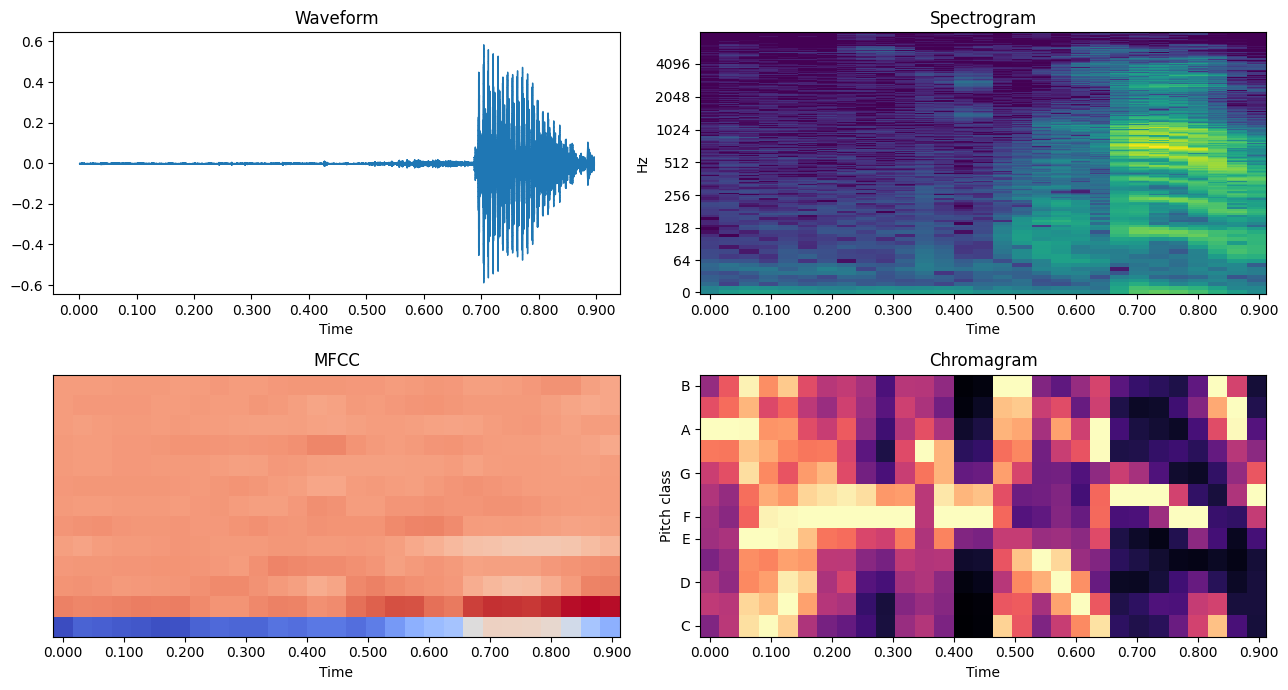

In [6]:
# ==== Cell 6: Visualization of one sample (optional) ====
audio_sample = audio_df[audio_df["label"] == audio_df["label"].unique()[0]]["audio_data"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Waveform
librosa.display.waveshow(audio_sample, sr=sampling_rate, ax=axes[0, 0])
axes[0, 0].set_title("Waveform")

# Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_sample)), ref=np.max)
librosa.display.specshow(D, sr=sampling_rate, x_axis="time", y_axis="log",
                         ax=axes[0, 1], cmap="viridis")
axes[0, 1].set_title("Spectrogram")

# MFCC
mfccs = librosa.feature.mfcc(y=audio_sample, sr=sampling_rate, n_mfcc=13)
librosa.display.specshow(mfccs, x_axis="time", sr=sampling_rate, ax=axes[1, 0])
axes[1, 0].set_title("MFCC")

# Chromagram
chroma = librosa.feature.chroma_stft(y=audio_sample, sr=sampling_rate)
librosa.display.specshow(chroma, y_axis="chroma", x_axis="time",
                         sr=sampling_rate, ax=axes[1, 1])
axes[1, 1].set_title("Chromagram")

plt.tight_layout()
plt.show()


In [ ]:
# ==== Cell 7: Split, pad and build DataLoaders ====

# features & labels
X_all = audio_df["scaled_mfcc"].values
y_all = audio_df["label"].values

# train / temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# val / test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(len(X_train), len(X_val), len(X_test))

# Padding
def pad_mfcc_list(mfcc_list, max_len=None):
    if max_len is None:
        max_len = max(m.shape[0] for m in mfcc_list)
    n_samples = len(mfcc_list)
    n_features = mfcc_list[0].shape[1]
    X_padded = np.zeros((n_samples, max_len, n_features), dtype=np.float32)
    for i, m in enumerate(mfcc_list):
        length = m.shape[0]
        X_padded[i, :length, :] = m
    return X_padded

global_max_len = max(m.shape[0] for m in X_all)

X_train_padded = pad_mfcc_list(X_train, max_len=global_max_len)
X_val_padded   = pad_mfcc_list(X_val,   max_len=global_max_len)
X_test_padded  = pad_mfcc_list(X_test,  max_len=global_max_len)

print("Train padded shape:", X_train_padded.shape)

# Label encoding
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

print("Classes:", list(label_encoder.classes_))
num_classes = len(label_encoder.classes_)

# Dataset
class MFCCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).unsqueeze(1)  # (N, 1, T, F)
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MFCCDataset(X_train_padded, y_train_enc)
val_dataset   = MFCCDataset(X_val_padded,   y_val_enc)
test_dataset  = MFCCDataset(X_test_padded,  y_test_enc)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


16967 2121 2121
Train padded shape: (16967, 32, 13)
Classes: ['house', 'learn', 'left', 'marvin', 'nine', 'no', 'off']


In [8]:
# ==== Cell 8: Basic DSCNN model ====
class BasicDSCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicDSCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)

        self.dw2   = nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=64)
        self.bn2   = nn.BatchNorm2d(64)
        self.pw2   = nn.Conv2d(64, 64, kernel_size=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.dw3   = nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=64)
        self.bn4   = nn.BatchNorm2d(64)
        self.pw3   = nn.Conv2d(64, 128, kernel_size=1)
        self.bn5   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)

        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = F.relu(self.bn2(self.dw2(x)))
        x = F.relu(self.bn3(self.pw2(x)))
        x = self.pool2(x)

        x = F.relu(self.bn4(self.dw3(x)))
        x = F.relu(self.bn5(self.pw3(x)))
        x = self.pool3(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc_out(x)
        return x


In [9]:
# ==== Cell 9: Improved DSCNN model ====
class ImprovedDSCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedDSCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)

        self.dw2   = nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=64)
        self.bn2   = nn.BatchNorm2d(64)
        self.pw2   = nn.Conv2d(64, 64, kernel_size=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        self.drop2 = nn.Dropout(0.3)

        self.dw3   = nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=64)
        self.bn4   = nn.BatchNorm2d(64)
        self.pw3   = nn.Conv2d(64, 128, kernel_size=1)
        self.bn5   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)
        self.drop3 = nn.Dropout(0.3)

        self.gap   = nn.AdaptiveAvgPool2d(1)
        self.fc1   = nn.Linear(128, 128)
        self.drop_fc = nn.Dropout(0.5)
        self.fc_out  = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = F.relu(self.bn2(self.dw2(x)))
        x = F.relu(self.bn3(self.pw2(x)))
        x = self.pool2(x)
        x = self.drop2(x)

        x = F.relu(self.bn4(self.dw3(x)))
        x = F.relu(self.bn5(self.pw3(x)))
        x = self.pool3(x)
        x = self.drop3(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc_out(x)
        return x


In [10]:
# ==== Cell 10: Generic train/eval utilities ====
criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, val_loader,
                num_epochs=150, patience=10,
                lr=1e-3, weight_decay=1e-3,
                model_name="model"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr,
                                 weight_decay=weight_decay)

    best_val_acc = 0.0
    epochs_no_improve = 0
    best_path = f"best_{model_name}.pt"

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []

    for epoch in range(1, num_epochs + 1):
        # --- Train ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (preds == y_batch).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # --- Validation ---
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_running_loss += loss.item() * X_batch.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += y_batch.size(0)
                val_correct += (preds == y_batch).sum().item()

        val_loss = val_running_loss / val_total
        val_acc  = val_correct / val_total

        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_path)
            print("  → New best model saved!")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    history = {
        "train_loss": train_loss_hist,
        "val_loss":   val_loss_hist,
        "train_acc":  train_acc_hist,
        "val_acc":    val_acc_hist,
        "best_path":  best_path,
        "best_val_acc": best_val_acc
    }
    return history

def evaluate_model(model_class, best_path, loader, model_name="model"):
    model = model_class(num_classes).to(device)
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()

    total, correct, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (preds == y_batch).sum().item()

    loss = running_loss / total
    acc  = correct / total
    print(f"[{model_name}] Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    return model

def plot_history(history, title_prefix=""):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], "bo-", label="Training Loss")
    plt.plot(epochs_range, history["val_loss"],   "r*-", label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Training and Validation Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_acc"], "bo-", label="Training Accuracy")
    plt.plot(epochs_range, history["val_acc"],   "r*-", label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Training and Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


Epoch   1/150 | Train loss: 1.1364, acc: 0.6486 | Val loss: 0.6371, acc: 0.8185
  → New best model saved!
Epoch   2/150 | Train loss: 0.4860, acc: 0.8565 | Val loss: 0.4227, acc: 0.8722
  → New best model saved!
Epoch   3/150 | Train loss: 0.3326, acc: 0.9015 | Val loss: 0.3139, acc: 0.8977
  → New best model saved!
Epoch   4/150 | Train loss: 0.2716, acc: 0.9156 | Val loss: 0.3019, acc: 0.9076
  → New best model saved!
Epoch   5/150 | Train loss: 0.2324, acc: 0.9270 | Val loss: 0.2592, acc: 0.9180
  → New best model saved!
Epoch   6/150 | Train loss: 0.2110, acc: 0.9358 | Val loss: 0.2781, acc: 0.9099
Epoch   7/150 | Train loss: 0.1925, acc: 0.9402 | Val loss: 0.2500, acc: 0.9142
Epoch   8/150 | Train loss: 0.1758, acc: 0.9450 | Val loss: 0.2083, acc: 0.9264
  → New best model saved!
Epoch   9/150 | Train loss: 0.1667, acc: 0.9487 | Val loss: 0.2558, acc: 0.9114
Epoch  10/150 | Train loss: 0.1611, acc: 0.9493 | Val loss: 0.2366, acc: 0.9198
Epoch  11/150 | Train loss: 0.1436, acc: 0.9

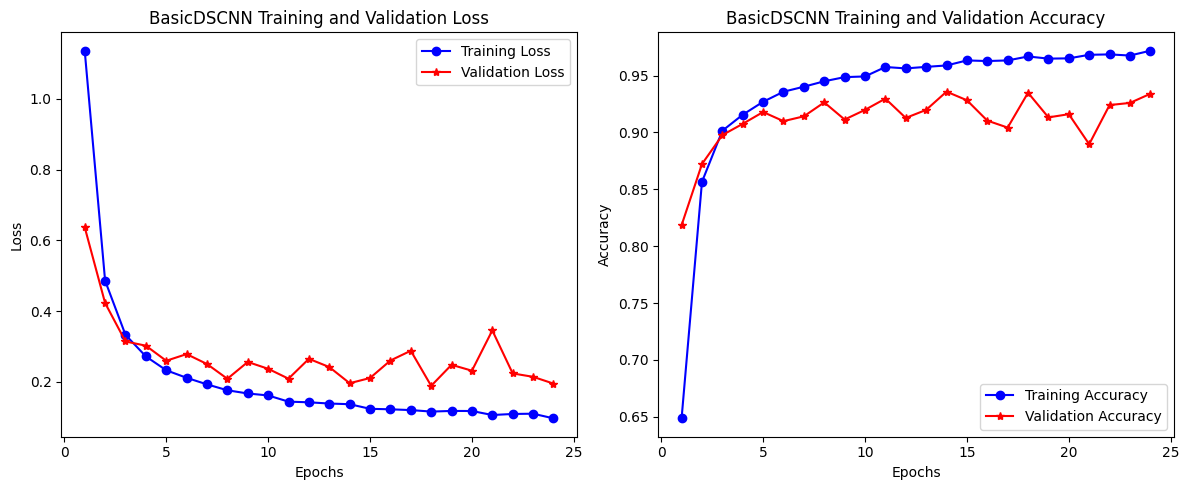

[BasicDSCNN (train)] Loss: 0.1091, Accuracy: 0.9699
[BasicDSCNN (val)] Loss: 0.1957, Accuracy: 0.9359


In [ ]:
# ==== Cell 11: Train BasicDSCNN (first model) ====
basic_model = BasicDSCNN(num_classes)
history_basic = train_model(
    basic_model,
    train_loader,
    val_loader,
    num_epochs=150,
    patience=10,
    lr=1e-3,
    weight_decay=1e-3,
    model_name="basic_dscnn"
)

plot_history(history_basic, title_prefix="BasicDSCNN")
best_basic_path = history_basic["best_path"]

_ = evaluate_model(BasicDSCNN, best_basic_path, train_loader, "BasicDSCNN (train)")
_ = evaluate_model(BasicDSCNN, best_basic_path, val_loader,   "BasicDSCNN (val)")


Epoch   1/150 | Train loss: 1.4410, acc: 0.4657 | Val loss: 0.8346, acc: 0.7209
  → New best model saved!
Epoch   2/150 | Train loss: 0.7860, acc: 0.7218 | Val loss: 0.5265, acc: 0.8241
  → New best model saved!
Epoch   3/150 | Train loss: 0.5907, acc: 0.7988 | Val loss: 0.4341, acc: 0.8633
  → New best model saved!
Epoch   4/150 | Train loss: 0.4942, acc: 0.8350 | Val loss: 0.3293, acc: 0.8901
  → New best model saved!
Epoch   5/150 | Train loss: 0.4280, acc: 0.8567 | Val loss: 0.3175, acc: 0.8854
Epoch   6/150 | Train loss: 0.3955, acc: 0.8684 | Val loss: 0.2803, acc: 0.9033
  → New best model saved!
Epoch   7/150 | Train loss: 0.3717, acc: 0.8798 | Val loss: 0.3089, acc: 0.8949
Epoch   8/150 | Train loss: 0.3384, acc: 0.8871 | Val loss: 0.2581, acc: 0.9052
  → New best model saved!
Epoch   9/150 | Train loss: 0.3305, acc: 0.8913 | Val loss: 0.2495, acc: 0.9180
  → New best model saved!
Epoch  10/150 | Train loss: 0.3086, acc: 0.8967 | Val loss: 0.2458, acc: 0.9114
Epoch  11/150 | Tr

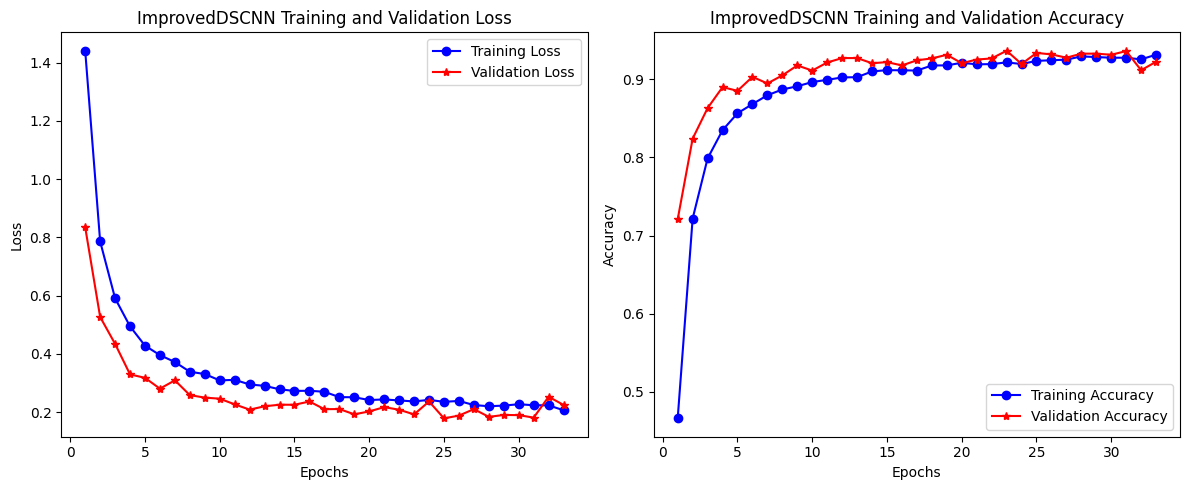

[ImprovedDSCNN (train)] Loss: 0.1441, Accuracy: 0.9536
[ImprovedDSCNN (val)] Loss: 0.1919, Accuracy: 0.9368


In [12]:
# ==== Cell 12: Train ImprovedDSCNN (second model) ====
improved_model = ImprovedDSCNN(num_classes)
history_improved = train_model(
    improved_model,
    train_loader,
    val_loader,
    num_epochs=150,
    patience=10,
    lr=1e-3,
    weight_decay=1e-3,
    model_name="improved_dscnn"
)

plot_history(history_improved, title_prefix="ImprovedDSCNN")
best_improved_path = history_improved["best_path"]

_ = evaluate_model(ImprovedDSCNN, best_improved_path, train_loader, "ImprovedDSCNN (train)")
_ = evaluate_model(ImprovedDSCNN, best_improved_path, val_loader,   "ImprovedDSCNN (val)")


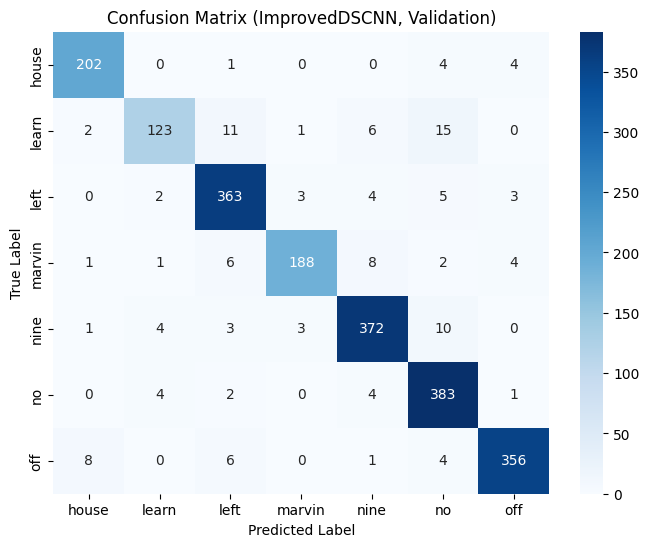

Classification Report (ImprovedDSCNN, Validation):
              precision    recall  f1-score   support

       house       0.94      0.96      0.95       211
       learn       0.92      0.78      0.84       158
        left       0.93      0.96      0.94       380
      marvin       0.96      0.90      0.93       210
        nine       0.94      0.95      0.94       393
          no       0.91      0.97      0.94       394
         off       0.97      0.95      0.96       375

    accuracy                           0.94      2121
   macro avg       0.94      0.92      0.93      2121
weighted avg       0.94      0.94      0.94      2121



In [13]:
# ==== Cell 13: Confusion matrix & report (ImprovedDSCNN on val) ====
best_model = ImprovedDSCNN(num_classes).to(device)
best_model.load_state_dict(torch.load(best_improved_path, map_location=device))
best_model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = best_model(X_batch)
        _, preds = torch.max(outputs, 1)

        all_true.extend(y_batch.numpy())
        all_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (ImprovedDSCNN, Validation)")
plt.show()

print("Classification Report (ImprovedDSCNN, Validation):")
print(classification_report(all_true, all_pred,
                            target_names=label_encoder.classes_))
